/tmp/ipykernel_29306/3803058349.py:65: RuntimeWarning: invalid value encountered in log10
  psf_log = np.log10(psf_data + psf_data.max()*1e-6)  # Better floor value


Figure saved as 'interferometric_psf.png'
PSF loaded successfully!
Shape: (160, 160)
FOV: 16.0″ × 16.0″
Pixel scale: 0.1000″/pixel
Peak intensity: 0.003448
PSF is NOT normalized (sum = -0.0087, should be ≈1 if normalized)
Dynamic range: 3.6e+05
Peak location: pixel (80, 80) = (0.00", 0.00")


NameError: name 'radial_profile' is not defined

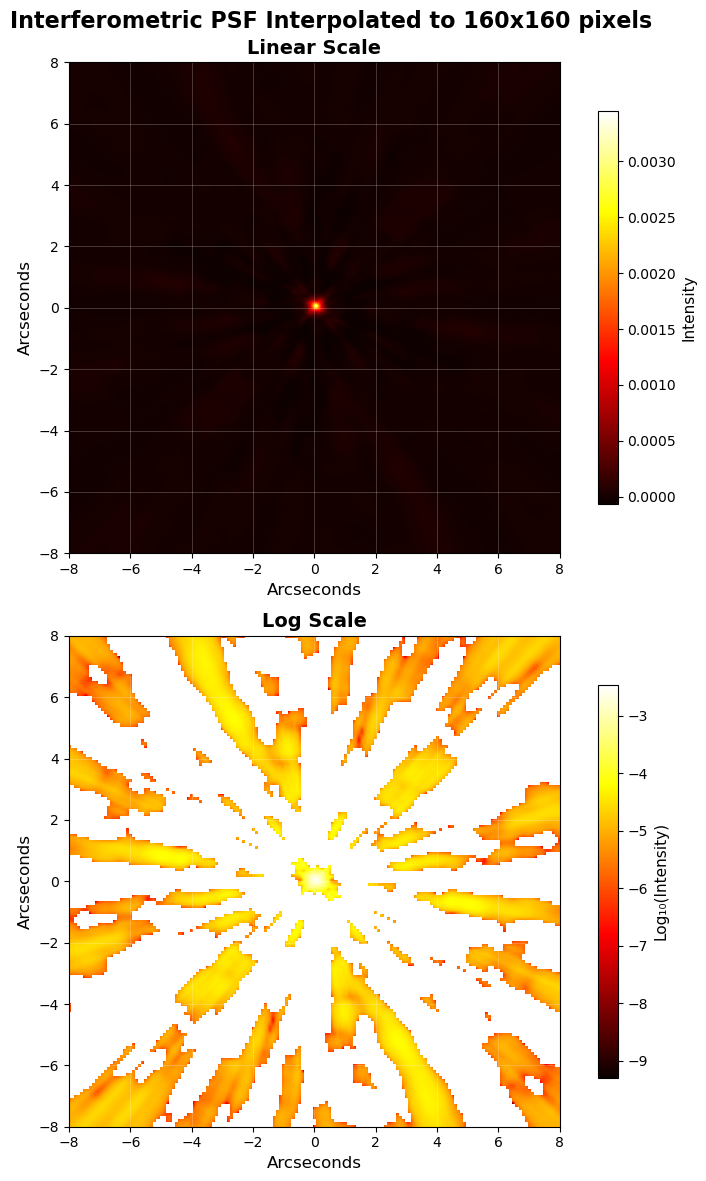

In [8]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Define the PSF class (simplified from your code)
class PthPSF:
    def __init__(self, psf_name, psf_dir="../psfs/processed_psfs"):
        # Adjust path as needed for your setup
        path = Path(psf_dir) / (psf_name + ".pth")
        psf_data = torch.load(path, weights_only=False, map_location='cpu')
        
        # Convert to tensor if it's a numpy array
        if isinstance(psf_data, np.ndarray):
            psf_tensor = torch.from_numpy(psf_data)
        else:
            psf_tensor = psf_data
            
        self.psf_tensor = psf_tensor.float().unsqueeze(0).unsqueeze(0)

    def get_tensor_psf(self, pixel_scale=None):
        return self.psf_tensor

def plot_interferometric_psf(save_figure=True):
    """
    Plot the interferometric PSF with proper scaling and labels.
    """
    
    # Load the PSF
    psf = PthPSF(psf_name="temp_bad_psf")
    psf_tensor = psf.get_tensor_psf()
    
    # Remove batch and channel dimensions for plotting
    psf_data = psf_tensor.squeeze().numpy()
    
    # PSF properties
    fov_arcsec = 16.0  # 16x16 arcsec field of view
    npix = psf_data.shape[0]  # Should be the same for both dimensions
    pixel_scale = fov_arcsec / npix  # arcsec per pixel
    
    # Create coordinate arrays in arcseconds
    coords_pix = np.arange(npix)
    coords_arcsec = (coords_pix - npix//2) * pixel_scale
    
    # Create the plot with 2 panels vertically stacked
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 12))
    
    # Plot 1: Linear scale
    im1 = ax1.imshow(psf_data, 
                     extent=[-fov_arcsec/2, fov_arcsec/2, -fov_arcsec/2, fov_arcsec/2],
                     origin='lower',
                     cmap='hot',
                     interpolation='bilinear')
    
    ax1.set_xlabel('Arcseconds', fontsize=12)
    ax1.set_ylabel('Arcseconds', fontsize=12)
    ax1.set_title('Linear Scale', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3, color='white', linewidth=0.5)
    
    # Add colorbar for linear
    cbar1 = plt.colorbar(im1, ax=ax1, shrink=0.8)
    cbar1.set_label('Intensity', fontsize=11)
    
    # Plot 2: Log scale  
    psf_log = np.log10(psf_data + psf_data.max()*1e-6)  # Better floor value
    
    im2 = ax2.imshow(psf_log, 
                     extent=[-fov_arcsec/2, fov_arcsec/2, -fov_arcsec/2, fov_arcsec/2],
                     origin='lower',
                     cmap='hot',
                     interpolation='bilinear')
    
    ax2.set_xlabel('Arcseconds', fontsize=12)
    ax2.set_ylabel('Arcseconds', fontsize=12)
    ax2.set_title('Log Scale', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, color='white', linewidth=0.5)
    
    # Add colorbar for log
    cbar2 = plt.colorbar(im2, ax=ax2, shrink=0.8)
    cbar2.set_label('Log₁₀(Intensity)', fontsize=11)
    
    # Add main title
    fig.suptitle('Interferometric PSF Interpolated to 160x160 pixels', fontsize=16, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    
    if save_figure:
        fig.savefig('interferometric_psf.png', dpi=150, bbox_inches='tight')
        print("Figure saved as 'interferometric_psf.png'")
    
    # Print comprehensive statistics
    print(f"PSF loaded successfully!")
    print(f"Shape: {psf_data.shape}")
    print(f"FOV: {fov_arcsec}″ × {fov_arcsec}″")
    print(f"Pixel scale: {pixel_scale:.4f}″/pixel")
    print(f"Peak intensity: {psf_data.max():.6f}")
    print(f"PSF is NOT normalized (sum = {psf_data.sum():.4f}, should be ≈1 if normalized)")
    print(f"Dynamic range: {psf_data.max()/psf_data[psf_data>0].min():.1e}")
    
    # PSF quality metrics
    peak_idx = np.unravel_index(np.argmax(psf_data), psf_data.shape)
    print(f"Peak location: pixel ({peak_idx[1]}, {peak_idx[0]}) = ({(peak_idx[1]-npix//2)*pixel_scale:.2f}\", {(peak_idx[0]-npix//2)*pixel_scale:.2f}\")")
    
    # Estimate FWHM from radial profile
    half_max = psf_data.max() / 2
    fwhm_idx = np.where(np.array(radial_profile) <= half_max)[0]
    if len(fwhm_idx) > 0:
        fwhm_estimate = r_centers[fwhm_idx[0]] * 2
        print(f"Estimated FWHM: {fwhm_estimate:.3f}\"")
    else:
        print("FWHM: Could not estimate (PSF may be undersampled)")
    
    return fig

# Alternative simple version for quick viewing
def plot_simple_psf():
    """
    Minimal version for quick PSF visualization.
    """
    psf = PthPSF(psf_name="temp_bad_psf")
    psf_data = psf.get_tensor_psf().squeeze().numpy()
    
    plt.figure(figsize=(8, 6))
    plt.imshow(psf_data, cmap='viridis', origin='lower')
    plt.colorbar(label='Intensity')
    plt.title('Interferometric PSF')
    plt.xlabel('Pixels')
    plt.ylabel('Pixels')
    plt.show()

if __name__ == "__main__":
    # Use the detailed version
    fig = plot_interferometric_psf(save_figure=True)
    plt.show()
    
    # Uncomment for simple version:
    # plot_simple_psf()